<a href="https://colab.research.google.com/github/sn-kc/AI-ML-CLASS/blob/main/wine_clustering_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Libraries

**import numpy as np:**

 Loads the NumPy library, which handles rapid mathematical calculations and multi-dimensional matrices.

**import pandas as pd:**

Loads the Pandas library, the core tool used for data manipulation, structured tables (DataFrames), and file reading.

**import seaborn as sns & import matplotlib.pyplot as plt:**

 Imports Python’s primary graphing tools. matplotlib handles the canvas creation, while seaborn makes advanced statistical grids easily.

**from tqdm import tqdm:**

 Imports a progress bar generator. When running loops that take a while, wrapping them in tqdm() prints a moving load-bar on screen.

 **import sklearn.cluster as cluster:**

  Imports Scikit-Learn’s unsupervised grouping algorithms.

**from sklearn.preprocessing import StandardScaler:**

 Pulls the standardization tool out of Scikit-Learn. K-Means clustering calculates visual distances between data coordinates.

 **from sklearn.metrics import silhouette_score**

The silhouette score evaluates how well-separated clusters are.


In [13]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import sklearn.cluster as cluster
from sklearn.metrics import silhouette_score


# saving wine data sheet as df

In [3]:
df=pd.read_csv

# Feature Scaling (Standardization) by standard scaler

In [7]:
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

std_scaler = StandardScaler()
data_cluster=df.copy()
data_cluster[data_cluster.columns]=std_scaler.fit_transform(data_cluster)

# Setting Display Formats & Plotting Libraries

In [5]:
pd.set_option('display.max_columns', None)
pd.options.display.float_format = "{:.2f}".format

# Checking for Missing Values

In [8]:
df.isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


# Dataset details

In [9]:
data_cluster.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.43,-1.43,-3.68,-2.67,-2.09,-2.11,-1.70,-1.87,-2.07,-1.63,-2.09,-1.90,-1.49
25%,-0.79,-0.66,-0.57,-0.69,-0.82,-0.89,-0.83,-0.74,-0.60,-0.80,-0.77,-0.95,-0.78
50%,0.06,-0.42,-0.02,0.00,-0.12,0.10,0.11,-0.18,-0.06,-0.16,0.03,0.24,-0.23
75%,0.84,0.67,0.70,0.60,0.51,0.81,0.85,0.61,0.63,0.49,0.71,0.79,0.76
max,2.26,3.11,3.16,3.15,4.37,2.54,3.06,2.40,3.49,3.44,3.30,1.96,2.97


# Finding the Optimal Number of Clusters (Elbow Method)

In [12]:
inertia = []
for i in tqdm(range(2,10)):
    kmeans = cluster.KMeans(n_clusters=i,
               init='k-means++',
               n_init=15,
               max_iter=500,
               random_state=17)
    kmeans.fit(data_cluster)
    inertia.append(kmeans.inertia_)

100%|██████████| 8/8 [00:00<00:00, 25.79it/s]


# Silhouette Analysis for cluster quality checking

In [14]:
silhouette = {}
for i in tqdm(range(2,10)):
    kmeans = cluster.KMeans(n_clusters=i,
               init='k-means++',
               n_init=15,
               max_iter=500,
               random_state=17)
    kmeans.fit(data_cluster)
    silhouette[i] = silhouette_score(data_cluster, kmeans.labels_, metric='euclidean')

100%|██████████| 8/8 [00:01<00:00,  7.42it/s]


# Visualization

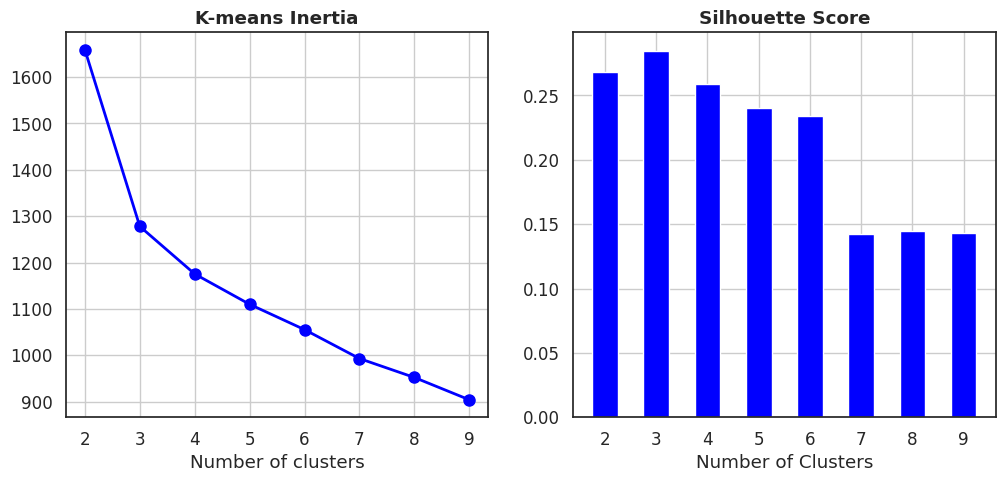

In [15]:
sns.set(style='white',font_scale=1.1, rc={'figure.figsize':(12,5)})

plt.subplot(1, 2, 1)

plt.plot(range(2,len(inertia)+2), inertia, marker='o',lw=2,ms=8,color='blue')
plt.xlabel('Number of clusters')
plt.title('K-means Inertia',fontweight='bold')
plt.grid(True)

plt.subplot(1, 2, 2)

plt.bar(range(len(silhouette)), list(silhouette.values()), align='center',color= 'blue',width=0.5)
plt.xticks(range(len(silhouette)), list(silhouette.keys()))
plt.grid()
plt.title('Silhouette Score',fontweight='bold')
plt.xlabel('Number of Clusters')


plt.show()